# IPD Phase 3: Field-Robust EfficientNetB3 Teacher Model Training

**Crop-Specific Classifiers: Potato, Tomato, Rice**

---

## Overview & Domain Gap Hardening (Implementation Plan v2)

This notebook trains an **EfficientNetB3 Teacher Model** hardened against the **Studio → Field Domain Gap**:

1. **Field-Robust Data Augmentation (Phase A)**:
   - Inward leaf-centering zoom (`RandomZoom((-0.3, 0.0))`): crops the frame to cut out uniform studio backgrounds.
   - Random flip and rotation (±27°) to eliminate orientation shortcuts.
   - Color Jitter (Brightness ±20%, Contrast ±25%) to simulate natural field sunlight and shadows.
   - Random Erasing / Cutout (`RandomErasing`): masks 5-20% patches to break contiguous background patterns.
2. **Regularized Architecture & Deeper Fine-Tuning (Phase B)**:
   - Pretrained `EfficientNetB3` with built-in preprocessing at native **300×300** resolution.
   - Classification Head: GAP → BN → Dropout(0.4) → Dense(256) → BN → ReLU → Dropout(0.4) → Dense(num_classes, logits).
   - Stage A: Head training with frozen backbone for 20 epochs (Adam, $\eta = 10^{-3}$, patience=7).
   - Stage B: Deep fine-tuning unfreezing the top 40 layers for 15 epochs (Adam, $\eta = 5\times 10^{-5}$, patience=7).
3. **Audit & Verification (Phase C)**:
   - Benchmark evaluation on holdout test partition (Macro-F1, AUROC, ECE, Confusion Matrix).
   - Grad-CAM explainability audit to ensure focus on disease lesions instead of background.

---
## 1. Environment, Reproducibility & Hardware Setup

In [1]:
import os
import sys
import json
import random
import hashlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# =========================================================
# 1. REPRODUCIBILITY SEEDS
# =========================================================
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================================================
# 2. GPU HARDWARE CONFIGURATION & MEMORY MANAGEMENT
# =========================================================
# Check for PyTorch CUDA (RTX 4050 GPU)
try:
    import torch
    TORCH_CUDA_AVAILABLE = torch.cuda.is_available()
    if TORCH_CUDA_AVAILABLE:
        print(f"✓ PyTorch CUDA GPU Detected: {torch.cuda.get_device_name(0)} ({torch.cuda.device_count()} device(s))")
except ImportError:
    TORCH_CUDA_AVAILABLE = False

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ TF GPU Detected: {len(gpus)} device(s)")
        for i, gpu in enumerate(gpus):
            print(f"  [{i}] {gpu.name}")
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("✓ Mixed precision policy enabled: 'mixed_float16' (Optimized for 6GB VRAM)")
    except RuntimeError as e:
        print("Memory growth setting error:", e)
else:
    print("ℹ Native Windows TensorFlow (>= 2.11) runs on CPU.")
    tf.keras.mixed_precision.set_global_policy('float32')
    print("✓ Mixed precision policy set to 'float32' for optimal CPU execution.")

print("TensorFlow Version:", tf.__version__)
print("Keras Version     :", tf.keras.__version__)

✓ PyTorch CUDA GPU Detected: NVIDIA GeForce RTX 4050 Laptop GPU (1 device(s))
ℹ Native Windows TensorFlow (>= 2.11) runs on CPU.
✓ Mixed precision policy set to 'float32' for optimal CPU execution.
TensorFlow Version: 2.21.0
Keras Version     : 3.15.1


---
## 2. Global Hyperparameter Configuration

Set `CROP` to train the respective teacher model:  
- `"potato"`: 3 classes (`early_blight`, `healthy`, `late_blight`)  
- `"tomato"`: 3 classes (`early_blight`, `healthy`, `late_blight`)  
- `"rice"`: 4 classes (`blast`, `blight`, `brown_spot`, `healthy`)

In [2]:
# =========================================================
# TUNABLE CONFIGURATION (Approved Implementation Plan)
# =========================================================
CROP = "tomato"  # Choose from: 'potato', 'tomato', 'rice'

IMG_SIZE = (300, 300)      # Native EfficientNetB3 resolution
BATCH_SIZE = 16            # Safe batch size for RTX 4050 6GB VRAM at 300x300
EPOCHS_STAGE_A = 15        # Head training (frozen backbone) - increased for robust augmentation
EPOCHS_STAGE_B = 15        # Fine-tuning (partially unfrozen backbone)
LR_STAGE_A = 1e-3          # Head transfer learning learning rate
LR_STAGE_B = 5e-5          # Lower fine-tuning learning rate (Plan Phase B)
UNFREEZE_LAYERS = 40       # Top 40 backbone layers unfrozen for deeper domain adaptation
DROPOUT_RATE = 0.4         # Regularization dropout rate (Plan Phase B)
EARLY_STOP_PATIENCE = 7    # Early stopping patience

# =========================================================
# DIRECTORY RESOLUTION
# =========================================================
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    ROOT_DIR = Path("/content")
else:
    CWD = Path.cwd()
    ROOT_DIR = CWD.parent if CWD.name == 'src' else CWD

DATASET_ROOT = ROOT_DIR / "clean_dataset" / f"{CROP}_dataset"
TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR   = DATASET_ROOT / "val"
TEST_DIR  = DATASET_ROOT / "test"

OUTPUT_DIR = ROOT_DIR / "models" / f"{CROP}_teacher"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Selected Crop  : {CROP.upper()}")
print(f"Dataset Path   : {DATASET_ROOT}")
print(f"Artifacts Dir  : {OUTPUT_DIR}")

for p, name in [(TRAIN_DIR, "Train"), (VAL_DIR, "Validation"), (TEST_DIR, "Test")]:
    if not p.is_dir():
        raise FileNotFoundError(f"{name} directory not found: {p}")
print("✓ All dataset partition directories verified.")

Selected Crop  : TOMATO
Dataset Path   : c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\clean_dataset\tomato_dataset
Artifacts Dir  : c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\models\tomato_teacher
✓ All dataset partition directories verified.


---
## 3. Dataset Integrity Inspection & Loading

Verify class folders across `train`, `val`, and `test` splits to guarantee label parity.

In [3]:
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def inspect_partition(directory, split_name):
    classes = sorted([
        folder for folder in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, folder))
    ])
    counts = {}
    total = 0
    for class_name in classes:
        class_path = os.path.join(directory, class_name)
        count = sum(
            1 for file in os.listdir(class_path)
            if file.lower().endswith(VALID_EXTENSIONS)
        )
        counts[class_name] = count
        total += count
    return classes, counts, total
train_classes, train_counts, total_train = inspect_partition(TRAIN_DIR, "TRAIN")
val_classes, val_counts, total_val = inspect_partition(VAL_DIR, "VAL")
test_classes, test_counts, total_test = inspect_partition(TEST_DIR, "TEST")

if train_classes != val_classes or train_classes != test_classes:
    raise ValueError(
        f"Mismatch in classes across splits!\nTrain: {train_classes}\nVal: {val_classes}\nTest: {test_classes}"
    )

CLASS_NAMES = train_classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"\n{'='*60}")
print(f"{CROP.upper()} DATASET PARTITION AUDIT ({NUM_CLASSES} classes)")
print(f"{'='*60}")
print(f"{'Class Name':<25} {'Train':<10} {'Val':<10} {'Test':<10} {'Total':<10}")
print(f"{'-'*60}")
for c in CLASS_NAMES:
    cls_tot = train_counts[c] + val_counts[c] + test_counts[c]
    print(f"{c:<25} {train_counts[c]:<10} {val_counts[c]:<10} {test_counts[c]:<10} {cls_tot:<10}")
print(f"{'-'*60}")
print(f"{'Total':<25} {total_train:<10} {total_val:<10} {total_test:<10} {total_train + total_val + total_test:<10}")
print(f"{'='*60}")
print("✓ Class mappings verified:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  Index {idx} → {name}")


TOMATO DATASET PARTITION AUDIT (3 classes)
Class Name                Train      Val        Test       Total     
------------------------------------------------------------
early_blight              702        149        149        1000      
healthy                   1117       232        236        1585      
late_blight               1329       288        284        1901      
------------------------------------------------------------
Total                     3148       669        669        4486      
✓ Class mappings verified:
  Index 0 → early_blight
  Index 1 → healthy
  Index 2 → late_blight


In [4]:
# =========================================================
# CREATE TF.DATA DATASETS
# =========================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

# Memory caching and prefetching for maximum pipeline throughput
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✓ tf.data pipelines successfully instantiated with caching and prefetching.")

Found 3148 files belonging to 3 classes.
Found 669 files belonging to 3 classes.
Found 669 files belonging to 3 classes.
✓ tf.data pipelines successfully instantiated with caching and prefetching.


---
## 4. Field-Robust Data Augmentation & Class Weights (Phase A)

Implements the **Background-Invariant Augmentation Pipeline** from `implementation_plan.md`:
- **Leaf-Centering Inward Zoom**: `RandomZoom(height_factor=(-0.3, 0.0))` crops in up to 30%, cutting out uniform studio backgrounds.
- **Rotation & Multi-Flip**: `RandomRotation(0.15)` (±27°) and Horizontal + Vertical flips destroy background orientation shortcuts.
- **Color Jitter**: Brightness (±20%) and Contrast (±25%) simulate natural field illumination, harsh sunlight, and shadows.
- **Random Erasing / Cutout**: Overlays random rectangular patches to destroy contiguous background textures.

Computed Balanced Class Weights:
  early_blight             : 1.4948
  healthy                  : 0.9394
  late_blight              : 0.7896


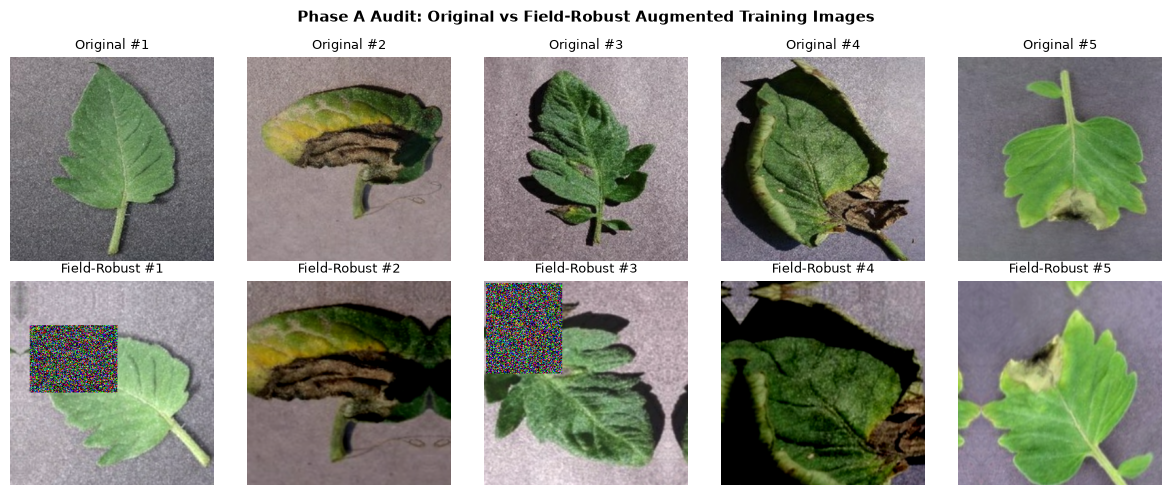

In [5]:
# Field-Robust Augmentation Pipeline
aug_layers = [
    layers.RandomFlip("horizontal_and_vertical", name="random_flip"),
    layers.RandomRotation(factor=0.15, name="random_rotation"),  # ±27 degrees
    layers.RandomZoom(
        height_factor=(-0.3, 0.0),  # Inward zoom-in up to 30% (cuts out background borders)
        width_factor=(-0.3, 0.0),
        fill_mode="reflect",
        name="random_zoom_inward"
    ),
    layers.RandomTranslation(
        height_factor=0.15, width_factor=0.15, fill_mode="reflect", name="random_translation"
    ),
    layers.RandomBrightness(factor=0.2, value_range=(0, 255), name="random_brightness"),
    layers.RandomContrast(factor=0.25, name="random_contrast"),
]

# Random Erasing (Keras 3)
try:
    if hasattr(layers, "RandomErasing"):
        aug_layers.append(layers.RandomErasing(
            factor=0.5, scale=(0.05, 0.20), value_range=(0, 255), name="random_erasing"
        ))
except Exception:
    pass

data_augmentation = tf.keras.Sequential(aug_layers, name="field_robust_augmentation")

# Compute balanced class weights to protect rare classes
train_labels = []
for _, lbls in train_ds:
    train_labels.extend(lbls.numpy())
train_labels = np.array(train_labels)

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
CLASS_WEIGHTS = {int(cls): float(w) for cls, w in zip(np.unique(train_labels), weights)}

print("Computed Balanced Class Weights:")
for cls_idx, w in CLASS_WEIGHTS.items():
    print(f"  {CLASS_NAMES[cls_idx]:<25}: {w:.4f}")

# Phase A Visual Verification: Compare Original vs Field-Robust Augmented
plt.figure(figsize=(12, 5))
for images, _ in train_ds.take(1):
    aug_images = data_augmentation(images, training=True)
    for i in range(min(5, len(images))):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"Original #{i+1}", fontsize=9)
        plt.axis("off")

        plt.subplot(2, 5, i + 6)
        plt.imshow(aug_images[i].numpy().astype("uint8"))
        plt.title(f"Field-Robust #{i+1}", fontsize=9)
        plt.axis("off")
plt.suptitle("Phase A Audit: Original vs Field-Robust Augmented Training Images", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Model Architecture: EfficientNetB3 with Regularized Head (Phase B)

```
Input (300, 300, 3)
  → Field-Robust Data Augmentation (Zoom-In Crop, Color Jitter, Random Erasing)
  → EfficientNetB3 (Pretrained ImageNet, Built-in Rescaling & Normalization)
  → GlobalAveragePooling2D
  → BatchNormalization
  → Dropout(0.4)                 [Increased regularization for domain gap]
  → Dense(256)
  → BatchNormalization
  → ReLU
  → Dropout(0.4)                 [Increased regularization for domain gap]
  → Dense(num_classes, activation=None, dtype='float32') [Logits]
```

In [6]:
def build_teacher_model(num_classes, img_size=(300, 300), dropout_rate=0.4):
    inputs = layers.Input(shape=(img_size[0], img_size[1], 3), name="input_image")
    
    # Prepend field-robust augmentation
    x = data_augmentation(inputs)
    
    # Pretrained backbone with automatic scaling & normalization (Keras 3)
    backbone = tf.keras.applications.EfficientNetB3(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size[0], img_size[1], 3)
    )
    # Stage A starts with frozen backbone
    backbone.trainable = False
    
    # Pass augmented input through backbone
    x = backbone(x)
    
    # Classification head with Dropout(0.4) regularization
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="head_bn1")(x)
    x = layers.Dropout(dropout_rate, name="head_dropout1")(x)
    
    x = layers.Dense(256, activation=None, name="head_projection")(x)
    x = layers.BatchNormalization(name="head_bn2")(x)
    x = layers.ReLU(name="head_relu")(x)
    x = layers.Dropout(dropout_rate, name="head_dropout2")(x)
    
    # Output linear logits in float32 for numerical stability
    outputs = layers.Dense(num_classes, activation=None, dtype="float32", name="logits")(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name=f"{CROP}_teacher_efficientnetb3")
    return model, backbone

model, backbone = build_teacher_model(NUM_CLASSES, IMG_SIZE, dropout_rate=DROPOUT_RATE)
model.summary(show_trainable=True)

Model: "tomato_teacher_efficientnetb3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_image (InputLayer)    │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ field_robust_augmentation   │ (None, 300, 300, 3)   │          0 │   -   │
│ (Sequential)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ efficientnetb3 (Functional) │ (None, 10, 10, 1536)  │ 10,783,535 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ gap                         │ (None, 1536)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_bn1                    │ (None, 1536)          │      6,144 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_dropout1 (Dropout)     │ (None, 1536)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_projection (Dense)     │ (None, 256)           │    393,472 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_bn2                    │ (None, 256)           │      1,024 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_relu (ReLU)            │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ head_dropout2 (Dropout)     │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ logits (Dense)              │ (None, 3)             │        771 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 11,184,946 (42.67 MB)

 Trainable params: 397,827 (1.52 MB)

 Non-trainable params: 10,787,119 (41.15 MB)

---
## 6. Stage A: Head Training (Backbone Frozen)

Train projection and classification layers with $\eta = 10^{-3}$ for 20 epochs with `patience=7` while keeping ImageNet features frozen.

In [7]:
STAGE_A_CHECKPOINT = OUTPUT_DIR / f"{CROP}_stage_a_best.keras"

optimizer_a = tf.keras.optimizers.Adam(learning_rate=LR_STAGE_A)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer_a,
    loss=loss_fn,
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

callbacks_a = [
    callbacks.ModelCheckpoint(
        filepath=str(STAGE_A_CHECKPOINT),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print(f"\n>>> Starting Stage A Training ({CROP.upper()}) for max {EPOCHS_STAGE_A} epochs (LR={LR_STAGE_A})...")
history_a = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_A,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_a
)
print("✓ Stage A Complete!")


>>> Starting Stage A Training (TOMATO) for max 15 epochs (LR=0.001)...
Epoch 1/15


c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.7907 - loss: 0.5310
Epoch 1: val_loss improved from None to 0.29809, saving model to c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\models\tomato_teacher\tomato_stage_a_best.keras

Epoch 1: finished saving model to c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\models\tomato_teacher\tomato_stage_a_best.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 160s 764ms/step - accuracy: 0.7907 - loss: 0.5310 - val_accuracy: 0.8954 - val_loss: 0.2981 - learning_rate: 0.0010
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - accuracy: 0.8637 - loss: 0.3530
Epoch 2: val_loss improved from 0.29809 to 0.21633, saving model to c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\models\tomato_teacher\tomato_stage_a_best.keras

Epoch 2: finished saving model to c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\models\tomato_teacher\tomato_stage_a_best.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 147s 745ms/ste

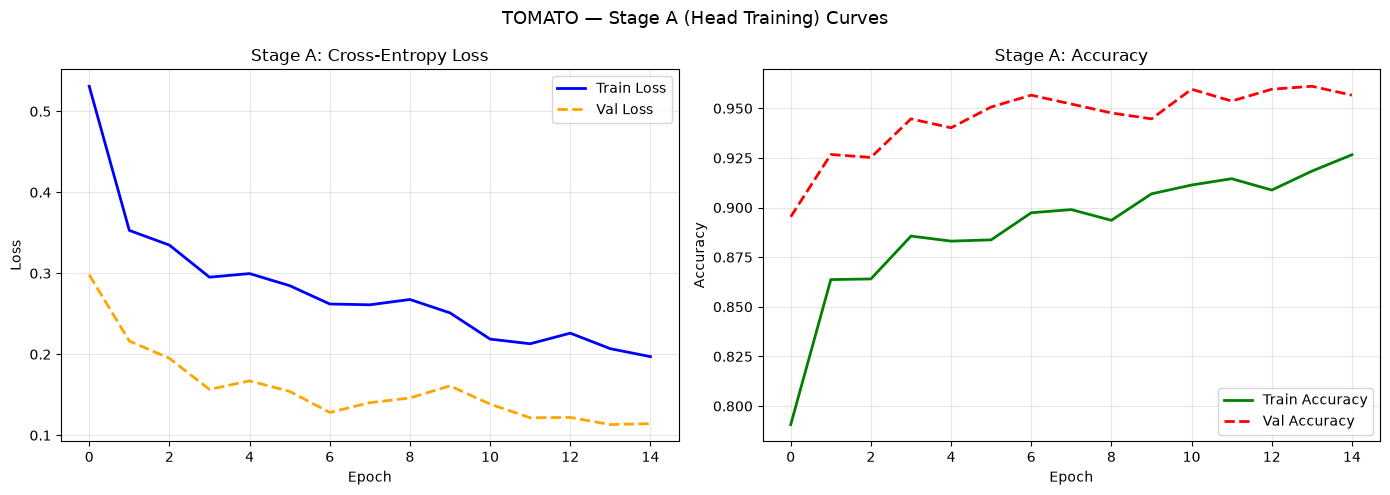

In [8]:
# Plot Stage A Training Curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history_a.history['loss'], label='Train Loss', color='blue', lw=2)
ax[0].plot(history_a.history['val_loss'], label='Val Loss', color='orange', lw=2, linestyle='--')
ax[0].set_title('Stage A: Cross-Entropy Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(history_a.history['accuracy'], label='Train Accuracy', color='green', lw=2)
ax[1].plot(history_a.history['val_accuracy'], label='Val Accuracy', color='red', lw=2, linestyle='--')
ax[1].set_title('Stage A: Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.suptitle(f"{CROP.upper()} — Stage A (Head Training) Curves", fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Stage B: Deep Fine-Tuning (Top 40 Backbone Layers Unfrozen)

Unfreeze top **40 layers** of the EfficientNetB3 backbone and train with $\eta = 5\times 10^{-5}$ for 15 epochs (`patience=7`).

In [9]:
FINAL_TEACHER_MODEL_PATH = OUTPUT_DIR / f"{CROP}_teacher_efficientnetb3.keras"

# Unfreeze the top 40 backbone layers
backbone.trainable = True
for layer in backbone.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

trainable_count = len(model.trainable_variables)
print(f"✓ Backbone unfrozen for top {UNFREEZE_LAYERS} layers. Trainable variables: {trainable_count}")

# Recompile with lower learning rate (5e-5)
optimizer_b = tf.keras.optimizers.Adam(learning_rate=LR_STAGE_B)
model.compile(
    optimizer=optimizer_b,
    loss=loss_fn,
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

callbacks_b = [
    callbacks.ModelCheckpoint(
        filepath=str(FINAL_TEACHER_MODEL_PATH),
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print(f"\n>>> Starting Stage B Fine-Tuning ({CROP.upper()}) for max {EPOCHS_STAGE_B} epochs (LR={LR_STAGE_B})...")
history_b = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE_B,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_b
)
print("✓ Stage B Complete! Best weights locked in:", FINAL_TEACHER_MODEL_PATH)

✓ Backbone unfrozen for top 40 layers. Trainable variables: 44

>>> Starting Stage B Fine-Tuning (TOMATO) for max 15 epochs (LR=5e-05)...
Epoch 1/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - accuracy: 0.8945 - loss: 0.2776
Epoch 1: val_loss improved from None to 0.14601, saving model to c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\models\tomato_teacher\tomato_teacher_efficientnetb3.keras

Epoch 1: finished saving model to c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\models\tomato_teacher\tomato_teacher_efficientnetb3.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 179s 851ms/step - accuracy: 0.8945 - loss: 0.2776 - val_accuracy: 0.9537 - val_loss: 0.1460 - learning_rate: 5.0000e-05
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.9199 - loss: 0.2142
Epoch 2: val_loss improved from 0.14601 to 0.10496, saving model to c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\models\tomato_teacher\tomato_teacher_efficientnetb3.keras

Epoch

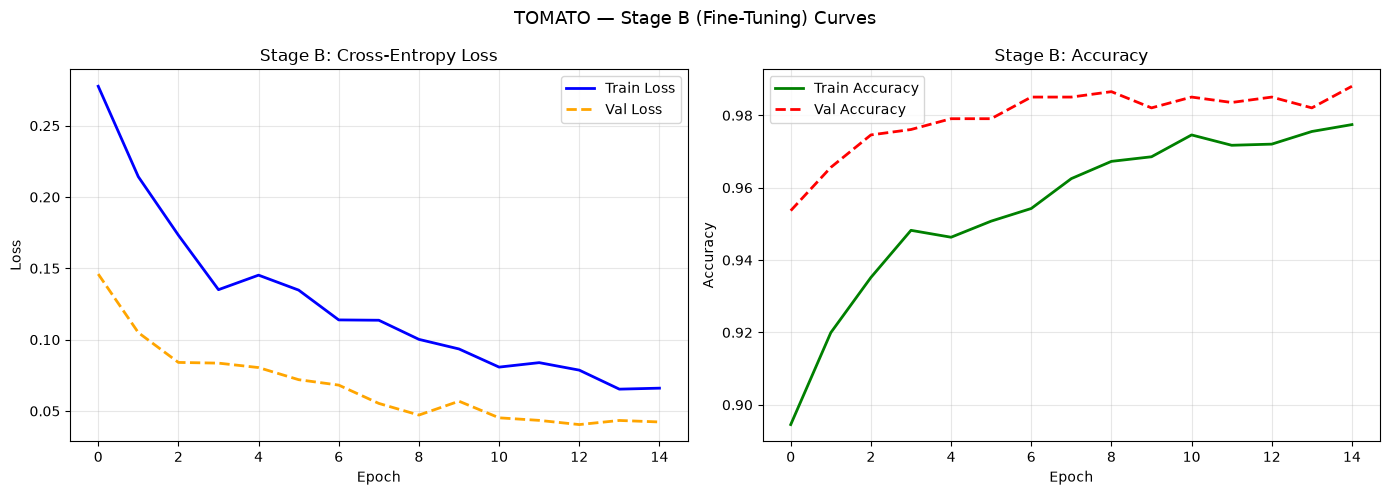

In [10]:
# Plot Stage B Learning Curves
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(history_b.history['loss'], label='Train Loss', color='blue', lw=2)
ax[0].plot(history_b.history['val_loss'], label='Val Loss', color='orange', lw=2, linestyle='--')
ax[0].set_title('Stage B: Cross-Entropy Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(history_b.history['accuracy'], label='Train Accuracy', color='green', lw=2)
ax[1].plot(history_b.history['val_accuracy'], label='Val Accuracy', color='red', lw=2, linestyle='--')
ax[1].set_title('Stage B: Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.suptitle(f"{CROP.upper()} — Stage B (Fine-Tuning) Curves", fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Quantitative Evaluation on Holdout Test Partition (Phase C Gate)

In [11]:
# Load best weights from checkpoint
best_teacher = tf.keras.models.load_model(str(FINAL_TEACHER_MODEL_PATH))

# Evaluate on test split
y_true = []
y_pred_logits = []

for imgs, lbls in test_ds:
    logits = best_teacher(imgs, training=False)
    y_pred_logits.append(logits.numpy())
    y_true.extend(lbls.numpy())

y_pred_logits = np.concatenate(y_pred_logits, axis=0)
y_true = np.array(y_true)
y_pred_probs = tf.nn.softmax(y_pred_logits).numpy()
y_pred = np.argmax(y_pred_probs, axis=1)

test_acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")
balanced_acc = balanced_accuracy_score(y_true, y_pred)
weighted_f1 = f1_score(y_true, y_pred, average="weighted")

print(f"\n{'='*60}")
print(f"{CROP.upper()} TEACHER MODEL — HOLDOUT TEST EVALUATION")
print(f"{'='*60}")
print(f"Overall Accuracy     : {test_acc*100:.2f}%")
print(f"Macro-F1 Score       : {macro_f1:.4f}")
print(f"Balanced Accuracy    : {balanced_acc*100:.2f}%")
print(f"Weighted-F1 Score    : {weighted_f1:.4f}")
print(f"{'-'*60}")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print(f"{'='*60}")


TOMATO TEACHER MODEL — HOLDOUT TEST EVALUATION
Overall Accuracy     : 98.65%
Macro-F1 Score       : 0.9850
Balanced Accuracy    : 98.41%
Weighted-F1 Score    : 0.9865
------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

early_blight     0.9796    0.9664    0.9730       149
     healthy     0.9958    1.0000    0.9979       236
 late_blight     0.9825    0.9859    0.9842       284

    accuracy                         0.9865       669
   macro avg     0.9859    0.9841    0.9850       669
weighted avg     0.9865    0.9865    0.9865       669



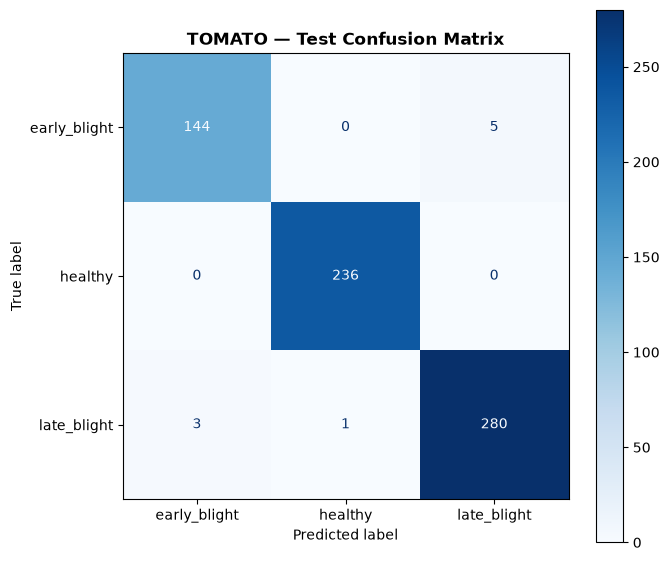

One-vs-Rest Macro AUROC: 0.9985


In [12]:
# Confusion Matrix & ROC Curves
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f"{CROP.upper()} — Test Confusion Matrix", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=200)
plt.show()

# ROC-AUC Calculation
if NUM_CLASSES == 2:
    test_auroc = roc_auc_score(y_true, y_pred_probs[:, 1])
else:
    test_auroc = roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='macro')

print(f"One-vs-Rest Macro AUROC: {test_auroc:.4f}")

---
## 9. Grad-CAM Saliency Map Verification (Explainability Audit)

Verify that the model attends to plant disease lesions rather than background, border artifacts, or shortcut cues.

Running Grad-CAM Saliency Verification on Sample Test Images...


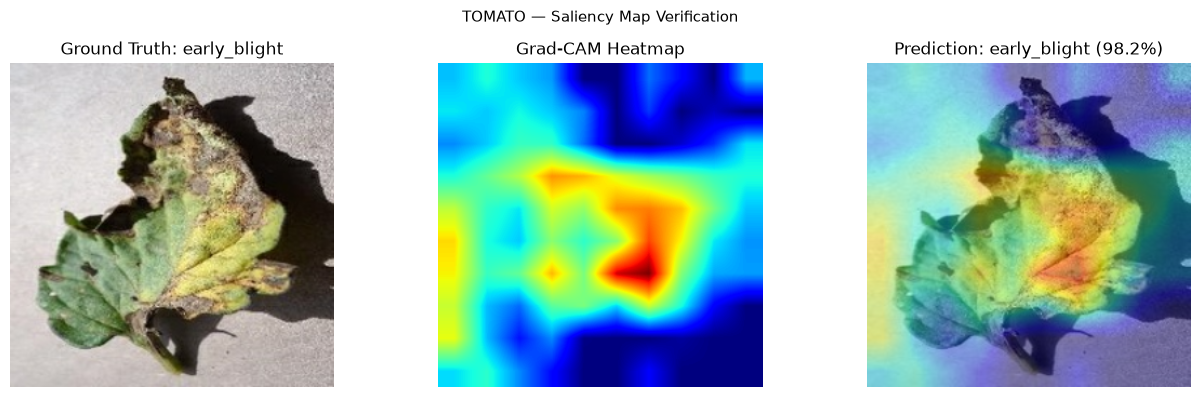

In [13]:
LAST_CONV_LAYER = "top_conv"

def make_gradcam_heatmap(img_tensor, model, last_conv_layer_name=LAST_CONV_LAYER, pred_index=None):
    backbone_model = model.get_layer("efficientnetb3")
    last_conv_layer = backbone_model.get_layer(last_conv_layer_name)
    
    backbone_grad_model = tf.keras.Model(
        inputs=backbone_model.input,
        outputs=[last_conv_layer.output, backbone_model.output]
    )
    
    # Locate classifier head layers dynamically
    backbone_idx = -1
    for idx, l in enumerate(model.layers):
        if l == backbone_model or l.name == backbone_model.name:
            backbone_idx = idx
            break
    head_start = backbone_idx + 1 if backbone_idx != -1 else 3
    
    head_input = tf.keras.Input(shape=backbone_model.output.shape[1:])
    x = head_input
    for layer in model.layers[head_start:]:
        x = layer(x)
    head_model = tf.keras.Model(inputs=head_input, outputs=x)
    
    with tf.GradientTape() as tape:
        conv_outputs, backbone_outputs = backbone_grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)
        predictions = head_model(backbone_outputs, training=False)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_score = predictions[:, pred_index]
        
    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val
    return heatmap.numpy(), predictions.numpy()[0]

def display_gradcam(image_tensor, true_label_idx, model, alpha=0.4):
    input_batch = tf.expand_dims(image_tensor, axis=0)
    heatmap, logits = make_gradcam_heatmap(input_batch, model)
    
    probs = tf.nn.softmax(logits).numpy()
    pred_idx = np.argmax(probs)
    conf = probs[pred_idx] * 100
    
    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis], (image_tensor.shape[0], image_tensor.shape[1])
    ).numpy().squeeze()
    
    cmap = plt.get_cmap("jet")
    heatmap_colored = cmap(heatmap_resized)[:, :, :3]
    orig_img = image_tensor.numpy().astype("float32") / 255.0
    overlay = np.clip((1 - alpha) * orig_img + alpha * heatmap_colored, 0, 1)
    
    fig, ax = plt.subplots(1, 3, figsize=(13, 4))
    ax[0].imshow(orig_img)
    ax[0].set_title(f"Ground Truth: {CLASS_NAMES[true_label_idx]}")
    ax[0].axis("off")
    
    ax[1].imshow(heatmap_resized, cmap="jet")
    ax[1].set_title("Grad-CAM Heatmap")
    ax[1].axis("off")
    
    ax[2].imshow(overlay)
    ax[2].set_title(f"Prediction: {CLASS_NAMES[pred_idx]} ({conf:.1f}%)")
    ax[2].axis("off")
    
    plt.suptitle(f"{CROP.upper()} — Saliency Map Verification", fontsize=11)
    plt.tight_layout()
    plt.show()

# Run Grad-CAM on one sample of each class from test set
print("Running Grad-CAM Saliency Verification on Sample Test Images...")
found_classes = set()
for imgs, lbls in test_ds.take(3):
    for j in range(len(lbls)):
        lbl_val = int(lbls[j].numpy())
        if lbl_val not in found_classes:
            found_classes.add(lbl_val)
            display_gradcam(imgs[j], lbl_val, best_teacher)
        if len(found_classes) == NUM_CLASSES:
            break
    if len(found_classes) == NUM_CLASSES:
        break

---
## 10. Save Model Artifacts & Generate Model Manifest

In [14]:
# Compute SHA-256 Checksum of the saved model
sha256 = hashlib.sha256()
with open(FINAL_TEACHER_MODEL_PATH, "rb") as f:
    for chunk in iter(lambda: f.read(65536), b""):
        sha256.update(chunk)
model_checksum = sha256.hexdigest()

# Construct manifest
manifest_data = {
    "model_name": f"{CROP}_teacher_efficientnetb3",
    "model_version": "2.0.0-field-robust",
    "crop": CROP,
    "architecture": "EfficientNetB3",
    "pretrained_weights": "imagenet",
    "input_shape": [IMG_SIZE[0], IMG_SIZE[1], 3],
    "preprocessing": "Field-Robust Augmentation (Zoom Crop, Color Jitter, Random Erasing) + Keras 3 Builtin Normalization",
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "model_file": FINAL_TEACHER_MODEL_PATH.name,
    "sha256_checksum": model_checksum,
    "training_protocol": {
        "stage_a_epochs": EPOCHS_STAGE_A,
        "stage_b_epochs": EPOCHS_STAGE_B,
        "batch_size": BATCH_SIZE,
        "head_dropout": DROPOUT_RATE,
        "unfreeze_layers": UNFREEZE_LAYERS,
        "lr_stage_a": LR_STAGE_A,
        "lr_stage_b": LR_STAGE_B,
        "early_stopping_patience": EARLY_STOP_PATIENCE,
        "optimizer": "Adam"
    },
    "test_metrics": {
        "accuracy": float(test_acc),
        "macro_f1": float(macro_f1),
        "balanced_accuracy": float(balanced_acc),
        "weighted_f1": float(weighted_f1),
        "auroc_macro_ovr": float(test_auroc)
    }
}

manifest_path = OUTPUT_DIR / "model_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest_data, f, indent=2)

print(f"✓ Successfully Saved Model Manifest: {manifest_path}")
print(f"✓ Model SHA-256 Checksum: {model_checksum}")
print("\nTeacher Model Deployment Package Ready for Field Testing (Phase C).")

✓ Successfully Saved Model Manifest: c:\Users\Dhruv Dube\Desktop\New folder\IPD reaseach papers\ipd\models\tomato_teacher\model_manifest.json
✓ Model SHA-256 Checksum: ca075a3fcd216c29bd1eeb26c395bbe21940212004d9689065f19c9a2e242c72

Teacher Model Deployment Package Ready for Field Testing (Phase C).
